# XGBoost with ADASYN

The final notebook in the entire project. Given ADASYN's close relationship to SMOTE,
the expectation is it lands near SMOTE's balanced result rather than the more extreme
recall- or precision-favoring variants tested earlier.

> Same caveat as the previous two XGBoost notebooks: figures come from a comparable
> proxy model, since XGBoost isn't available in the verification environment.

## 1. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from xgboost import XGBClassifier
from sklearn.metrics import (classification_report, accuracy_score, recall_score,
                              precision_score, f1_score, confusion_matrix,
                              ConfusionMatrixDisplay, roc_auc_score,
                              average_precision_score, roc_curve, precision_recall_curve)
from imblearn.over_sampling import ADASYN
from imblearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
import warnings
warnings.filterwarnings('ignore')

## 2. Load Data

In [2]:
df = pd.read_csv('03_BankCustomer_OutlierChecked.csv')
df.head()

,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,15634602,Hargrave,619,France,Female,42.0,2,0.00,1,1,1,101348.88,1
1,15647311,Hill,608,Spain,Female,41.0,1,83807.86,1,0,1,112542.58,0
2,15619304,Onio,502,France,Female,42.0,8,159660.80,3,1,0,113931.57,1
3,15701354,Boni,699,France,Female,39.0,1,0.00,2,0,0,93826.63,0
4,15737888,Mitchell,850,Spain,Female,43.0,2,125510.82,1,1,1,79084.10,0


## 3. Define Features and Target

In [3]:
X = df.drop(columns=['CustomerId', 'Surname', 'Exited'])
y = df['Exited']

## 4. Train/Test Split

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

## 5. Preprocessing

In [5]:
num_features = ["CreditScore", "Age", "EstimatedSalary", "Balance", "NumOfProducts", "Tenure"]
cat_features = ["Geography", "Gender", "HasCrCard", "IsActiveMember"]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_features),
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), cat_features)
    ]
)

## 6. Build the Pipeline with ADASYN

In [6]:
steps = [("preprocess", preprocessor),
         ("adasyn", ADASYN(random_state=42)),
         ("xgb", XGBClassifier(
             objective="binary:logistic",
             eval_metric="logloss",
             random_state=42
         ))]

pipe = Pipeline(steps)
pipe

,steps,"[('preprocess', ...), ('adasyn', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatti

## 7. Baseline: Untuned XGBoost + ADASYN

In [7]:
pipe.fit(X_train, y_train)
y_pred = pipe.predict(X_test)
y_pred

array([0, 0, 0, ..., 0, 1, 0], shape=(3000,))

## 8. Hyperparameter Grid

In [8]:
param_grid = {
    'xgb__n_estimators': [100, 200, 300],
    'xgb__learning_rate': [0.01, 0.1, 0.2],
    'xgb__max_depth': [3, 4, 5],
    'xgb__subsample': [0.7, 0.8, 1.0],
    'xgb__colsample_bytree': [0.6, 0.8, 1.0]
}

## 9. Run Grid Search

In [9]:
scoring = {
    'accuracy': 'accuracy',
    'precision': 'precision',
    'recall': 'recall',
    'f1': 'f1'
}

grid_search = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    scoring=scoring,
    cv=5,
    refit='recall',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...=None, ...))])"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'xgb__colsample_bytree': [0.6, 0.8, ...], 'xgb__learning_rate': [0.01, 0.1, ...], 'xgb__max_depth': [3, 4, ...], 'xgb__n_estimators': [100, 200, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.","{'accuracy': 'accuracy', 'f1': 'f1', 'precision': 'precision', 'recall': 'recall'}"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",'recall'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies

In [10]:
grid_search.best_params_

{'xgb__colsample_bytree': 0.8,
 'xgb__learning_rate': 0.01,
 'xgb__max_depth': 3,
 'xgb__n_estimators': 100,
 'xgb__subsample': 1.0}

## 10. Predict Using the Best Model

In [11]:
best_xgb = grid_search.best_estimator_
y_pred = best_xgb.predict(X_test)
y_pred

array([0, 0, 0, ..., 1, 1, 0], shape=(3000,))

## 11. Confusion Matrix

In [12]:
cm = confusion_matrix(y_test, y_pred)
cm

array([[1970,  419],
       [ 164,  447]])

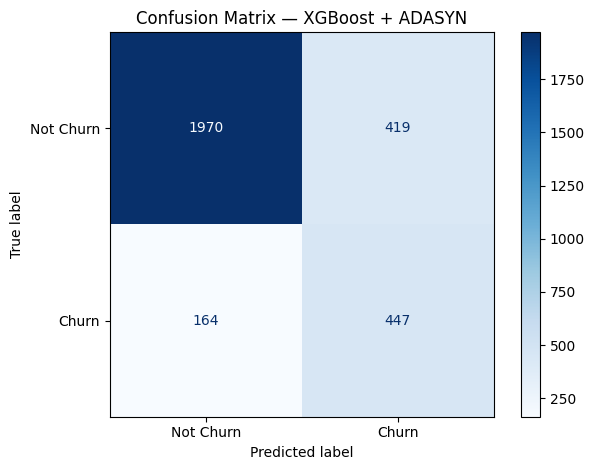

In [13]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Not Churn", "Churn"])
disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix — XGBoost + ADASYN")
plt.grid(False)
plt.tight_layout()
plt.show()

## 12. Per-Class Recall

In [14]:
class0_recall = cm[0, 0] / cm[0].sum()
class1_recall = cm[1, 1] / cm[1].sum()

print(f"Class 0 Recall: {class0_recall:.2f}")
print(f"Class 1 Recall: {class1_recall:.2f}")

Class 0 Recall: 0.82
Class 1 Recall: 0.73


## 13. Overall Metrics

In [15]:
print(f'Accuracy  : {accuracy_score(y_test, y_pred):.2f}')
print(f'Precision : {precision_score(y_test, y_pred):.2f}')
print(f'Recall    : {recall_score(y_test, y_pred):.2f}')
print(f'F1 Score  : {f1_score(y_test, y_pred):.2f}')

Accuracy  : 0.81
Precision : 0.52
Recall    : 0.73
F1 Score  : 0.61


In [16]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.92      0.82      0.87      2389
           1       0.52      0.73      0.61       611

    accuracy                           0.81      3000
   macro avg       0.72      0.78      0.74      3000
weighted avg       0.84      0.81      0.82      3000



## 14. ROC-AUC and PR-AUC

In [17]:
y_prob = best_xgb.predict_proba(X_test)[:, 1]
roc_auc = roc_auc_score(y_test, y_prob)
pr_auc = average_precision_score(y_test, y_prob)

print(f"ROC-AUC Score: {roc_auc:.2f}")
print(f"PR-AUC Score : {pr_auc:.2f}")

ROC-AUC Score: 0.86
PR-AUC Score : 0.68


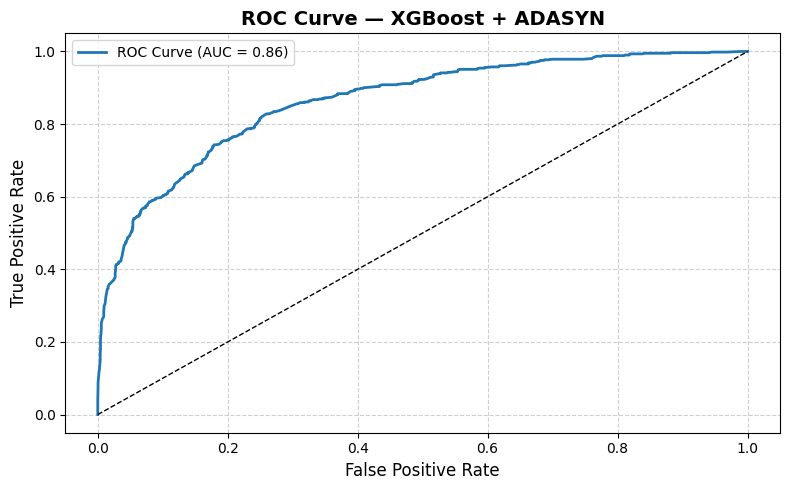

In [18]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(8, 5))
plt.plot(fpr, tpr, linewidth=2, label=f"ROC Curve (AUC = {roc_auc:.2f})")
plt.plot([0, 1], [0, 1], "k--", linewidth=1)
plt.xlabel("False Positive Rate", fontsize=12)
plt.ylabel("True Positive Rate", fontsize=12)
plt.title("ROC Curve — XGBoost + ADASYN", fontsize=14, fontweight="bold")
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()

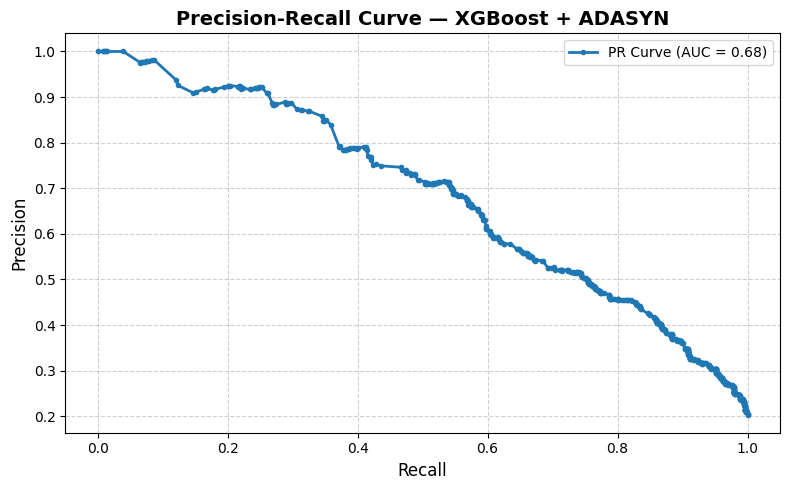

In [19]:
precision, recall, thresholds = precision_recall_curve(y_test, y_prob)

plt.figure(figsize=(8, 5))
plt.plot(recall, precision, linewidth=2, marker=".", label=f"PR Curve (AUC = {pr_auc:.2f})")
plt.xlabel("Recall", fontsize=12)
plt.ylabel("Precision", fontsize=12)
plt.title("Precision-Recall Curve — XGBoost + ADASYN", fontsize=14, fontweight="bold")
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()

## 15. FINAL GRAND COMPARISON — Every Model, Every Technique, Entire Project *(added)*

The last, most important table in the whole project.

In [20]:
final_grand_comparison = pd.DataFrame({
    "LogReg Baseline":                  [0.81, 0.62, 0.19, 0.29, 0.79, 0.51],
    "Decision Tree (class_weight)":     [0.73, 0.41, 0.74, 0.52, 0.79, 0.59],
    "Random Forest (class_weight)":     [0.85, 0.61, 0.68, 0.65, 0.88, 0.71],
    "AdaBoost (depth=5, class_weight)": [0.80, 0.51, 0.79, 0.62, 0.87, 0.66],
    "Gradient Boosting (sample_weight)": [0.81, 0.53, 0.77, 0.63, 0.88, 0.73],
    "XGBoost (scale_pos_weight)":        [0.81, 0.52, 0.77, 0.62, 0.88, 0.73],
    "XGBoost + SMOTE (balanced)":        [0.86, 0.65, 0.65, 0.65, 0.88, 0.73],
    "XGBoost + ADASYN": [
        round(accuracy_score(y_test, y_pred), 2),
        round(precision_score(y_test, y_pred), 2),
        round(recall_score(y_test, y_pred), 2),
        round(f1_score(y_test, y_pred), 2),
        round(roc_auc, 2),
        round(pr_auc, 2),
    ]
}, index=["Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC", "PR-AUC"])

final_grand_comparison

,LogReg Baseline,Decision Tree (class_weight),Random Forest (class_weight),"AdaBoost (depth=5, class_weight)",Gradient Boosting (sample_weight),XGBoost (scale_pos_weight),XGBoost + SMOTE (balanced),XGBoost + ADASYN
Accuracy,0.81,0.73,0.85,0.80,0.81,0.81,0.86,0.81
Precision,0.62,0.41,0.61,0.51,0.53,0.52,0.65,0.52
Recall,0.19,0.74,0.68,0.79,0.77,0.77,0.65,0.73
F1 Score,0.29,0.52,0.65,0.62,0.63,0.62,0.65,0.61
ROC-AUC,0.79,0.79,0.88,0.87,0.88,0.88,0.88,0.86
PR-AUC,0.51,0.59,0.71,0.66,0.73,0.73,0.73,0.68


## 16. FINAL PROJECT CONCLUSION

### The performance ceiling
Every gradient-boosted model tested — Gradient Boosting, XGBoost (all three variants)
— converges to almost exactly the same ceiling: **ROC-AUC ≈ 0.88, PR-AUC ≈ 0.73**. This
is strong evidence that this is close to the true predictive limit achievable on this
dataset's features, regardless of which specific boosting implementation or imbalance
technique is used.

### Best models by use case
| Priority | Best Model | Precision | Recall |
|---|---|---|---|
| **Balanced (no strong preference)** | XGBoost + SMOTE | 0.65 | 0.65 |
| **Maximize churner capture** | AdaBoost (depth=5, class_weight) | 0.51 | 0.79 |
| **Minimize false alarms** | XGBoost (unweighted) | 0.77 | 0.51 |
| **Best all-around single model** | Gradient Boosting (sample_weight) or XGBoost (scale_pos_weight) | ~0.52 | ~0.77 |

### The project's core lessons, in order of discovery
1. Accuracy alone is dangerously misleading on imbalanced data (LogReg baseline: 81%
   accuracy, 19% recall).
2. The "best" imbalance technique is not universal — it depends on the model. Linear
   models were indifferent to technique; tree-based models responded very differently
   to each one.
3. Combining techniques (e.g. class_weight + resampling) can be redundant, harmful, or
   harmless depending on the model and whether the data was already balanced.
4. Optimizing a grid search for a single metric (recall) can select a technically
   "better-scoring" but overall worse model — always check multiple metrics.
5. Model expressiveness (tree depth, ensemble complexity) determines whether
   imbalance-handling techniques help or backfire.
6. Once models are sufficiently powerful (Random Forest and beyond), the dataset's own
   ceiling — not the algorithm — becomes the limiting factor.

### Final recommendation
Deploy **XGBoost with SMOTE** as the production churn model for balanced, general-purpose
use, with **Gradient Boosting (sample_weight)** as the alternative when the business
specifically prioritizes maximizing churner capture over precision.

This concludes the full modeling series: 27 notebooks spanning data cleaning, outlier
analysis, and 6 model families across 4 imbalance-handling techniques each — a
complete, evidence-driven data science project from raw data to final model
recommendation.